# Context
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering - Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.

This data consists of 20 columns and 4888 rows

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("Travel.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


# Data cleaning

# Handling missing values
1. handling duplicates
2. check data types
3. Understand the dataset

In [3]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [4]:
# check all the categories
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [5]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [6]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [7]:
df['Designation'].value_counts()

Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64

In [8]:
df['Gender']= df['Gender'].replace('Fe Male', 'Female')
df['MaritalStatus']= df['MaritalStatus'].replace('Single', 'Unmarried')

In [9]:
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [10]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64

In [11]:
df['Occupation'].value_counts()

Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64

In [12]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [13]:
# checking missing values
features_with_na= [features for features in df.columns if df[features].isnull().sum() >=1 ]

In [14]:
features_with_na

['Age',
 'TypeofContact',
 'DurationOfPitch',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [15]:
#to find the percentage of the missing values
for feature in features_with_na:
    print(feature, np.round(df[feature].isnull().mean()*100, 2), '% missing values')

Age 4.62 % missing values
TypeofContact 0.51 % missing values
DurationOfPitch 5.14 % missing values
NumberOfFollowups 0.92 % missing values
PreferredPropertyStar 0.53 % missing values
NumberOfTrips 2.86 % missing values
NumberOfChildrenVisiting 1.35 % missing values
MonthlyIncome 4.77 % missing values


In [16]:
# stats on numerical columns (Null cols)
df[features_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


# Imputing null values
1. Impute median values for Age column
2. Impute mode for type of contract
3. Impute median for Duration of pitch 
4. Impute mode for numberOfFollowups as it is a discrete feature
5. Impute mode for PreferredProepertyStar
6. Impute median for numberOfTrips
7. Impute mode for NumberOfChildrenvisiting
8. Impute median for MonthlyIncome

In [17]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [18]:

#imputing values
df.fillna({'MonthlyIncome' :df.MonthlyIncome.median(),
           'NumberOfChildrenVisiting' :df.NumberOfChildrenVisiting.mode()[0],
           'NumberOfTrips' :df.NumberOfTrips.median(),
           'PreferredPropertyStar' :df.PreferredPropertyStar.mode()[0],
           'NumberOfFollowups' :df.NumberOfFollowups.mode()[0],
           'DurationOfPitch' :df.DurationOfPitch.median(),
           'TypeofContact' :df.TypeofContact.mode()[0],
           'Age' :df.Age.median()
           }, inplace=True)

In [19]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [20]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [21]:
df.drop('CustomerID', axis=1, inplace=True)

# Feature engineering

In [22]:
# create new column for feature
df['TotalVisiting']= df['NumberOfChildrenVisiting'] + df['NumberOfPersonVisiting']
df.drop(columns=['NumberOfChildrenVisiting', 'NumberOfPersonVisiting'], axis=1, inplace=True)

In [23]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [24]:
# get all the numeric features
num_features=[feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of Numerical features are ', len(num_features))


Num of Numerical features are  12


In [25]:
# categorical feautes
cat_features= [feature for feature in df.columns if df[feature].dtype=='O']
print("Number of categorical features are ", len(cat_features))

Number of categorical features are  6


In [26]:
# Discrete feautre
# those features which have fixed number of categories
dis_feature= [feature for feature in df.columns if len(df[feature].unique())<=25]
print('Discrete features are ', len(dis_feature))

Discrete features are  15


In [27]:
# continuous features
conti_features= [feature for feature in df.columns if feature not in dis_feature]
print('Continuous features are ', len(conti_features))

Continuous features are  3


In [28]:
# train test split
x=df.drop(['ProdTaken'], axis=1)
y=df['ProdTaken']
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test=  train_test_split(x,y,test_size=0.3 , random_state=33)

In [29]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [30]:
# create columns transformer with 3 types of transformers
cat_features= x.select_dtypes(include='object').columns

num_features= x.select_dtypes(exclude='object').columns

from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer
''' 
ColumnTransformer is used to apply different preprocessing steps to different columns of your data — especially useful when you're working with both numerical and categorical features.
'''
# standard scalar for num_feautres and OHE for cat_features

num_transformer=StandardScaler()
Onehot_transformer=OneHotEncoder(drop='first')
preprocessor= ColumnTransformer(
    [
    ('OneHotEncoder' , Onehot_transformer , cat_features),
    ('StandardScaler' , num_transformer , num_features)
    ]
)

In [31]:
x_train=preprocessor.fit_transform(x_train)

# for training dataset apply fit_transform and transform for test data

In [32]:
x_train

array([[ 1.        ,  1.        ,  0.        , ...,  0.78483501,
        -0.31527889,  2.05949796],
       [ 1.        ,  0.        ,  0.        , ...,  0.78483501,
        -0.67909207,  0.65348269],
       [ 1.        ,  0.        ,  0.        , ...,  0.78483501,
         2.91363645,  2.05949796],
       ...,
       [ 1.        ,  1.        ,  0.        , ..., -1.27415315,
        -0.51607088,  0.65348269],
       [ 0.        ,  0.        ,  1.        , ...,  0.78483501,
        -0.49141222,  0.65348269],
       [ 1.        ,  0.        ,  0.        , ...,  0.78483501,
        -0.11605252, -1.45554022]], shape=(3421, 26))

In [33]:
pd.DataFrame(x_train)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.462667,-1.001466,0.299669,0.529295,-0.109716,1.546120,0.673127,0.784835,-0.315279,2.059498
1,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.372756,-0.529758,0.299669,0.529295,-1.226791,1.546120,1.406726,0.784835,-0.679092,0.653483
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-0.717156,-1.001466,0.299669,-0.723798,1.007360,1.546120,-1.527670,0.784835,2.913636,2.059498
3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.717156,-1.119393,-0.700494,-0.723798,-1.226791,-0.646781,-0.060472,0.784835,-0.992414,-0.752533
4,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,-0.717156,0.059877,0.299669,1.782388,-0.109716,-0.646781,0.673127,0.784835,0.066148,-0.049525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3416,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.717156,1.592928,-0.700494,1.782388,0.448822,1.546120,0.673127,0.784835,-0.223885,-2.158548
3417,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.462667,0.059877,0.299669,1.782388,-0.668253,1.546120,-0.060472,-1.274153,0.667545,1.356490
3418,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,-0.717156,-0.765612,1.299831,1.782388,1.565897,-0.646781,0.673127,-1.274153,-0.516071,0.653483
3419,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.717156,-0.883539,-2.700818,1.782388,2.124435,1.546120,-0.794071,0.784835,-0.491412,0.653483


In [34]:
x_test=preprocessor.transform(x_test)

In [35]:
x_test

array([[ 1.        ,  1.        ,  0.        , ...,  0.78483501,
        -1.20377369,  0.65348269],
       [ 0.        ,  0.        ,  1.        , ..., -1.27415315,
        -0.61118288, -1.45554022],
       [ 1.        ,  0.        ,  1.        , ..., -1.27415315,
        -0.21292585, -0.75253258],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  0.78483501,
         0.57595576, -0.04952495],
       [ 1.        ,  0.        ,  0.        , ...,  0.78483501,
         0.39375561, -0.04952495],
       [ 1.        ,  0.        ,  0.        , ..., -1.27415315,
        -0.66950259, -0.04952495]], shape=(1467, 26))

In [38]:
# Random forest classifier model
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier , GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report , precision_score , f1_score , roc_auc_score , recall_score

In [39]:
models={
    'Random forest':RandomForestClassifier(),
    'Decision Tree':DecisionTreeClassifier(),
    'Logistic regression':LogisticRegression(),
    'Adaboost':AdaBoostClassifier(),
    'Gradient boost': GradientBoostingClassifier()
}
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train , y_train)
    
    y_train_pred= model.predict(x_train)
    y_test_pred= model.predict(x_test)
    
    #training set performance
    model_train_acc=accuracy_score(y_train , y_train_pred)
    model_train_f1= f1_score(y_train , y_train_pred , average='weighted')
    model_train_precision= precision_score(y_train , y_train_pred)
    model_train_recall= recall_score(y_train , y_train_pred)
    model_train_rocauc= roc_auc_score(y_train , y_train_pred)
    
    #test set performance
    model_test_acc=accuracy_score(y_test , y_test_pred)
    model_test_f1= f1_score(y_test , y_test_pred , average='weighted')
    model_test_precision= precision_score(y_test , y_test_pred)
    model_test_recall= recall_score(y_test , y_test_pred)
    model_test_rocauc= roc_auc_score(y_test , y_test_pred)
    
    print(list(models.keys())[i])
    
    print('Model performance for training set')
    print('- Acuuracy :{:.4f}'.format(model_train_acc))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    print('- Precision : {:.4f}'.format(model_train_precision))
    print('- Recall : {:.4f}'.format(model_train_recall))
    print('- Roc auc SCore : {:.4f}'.format(model_train_rocauc))
    
    print('='*35)
    
    print('Model performance for test set')
    print('- Acuuracy :{:.4f}'.format(model_test_acc))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision : {:.4f}'.format(model_test_precision))
    print('- Recall : {:.4f}'.format(model_test_recall))
    print('- Roc auc SCore : {:.4f}'.format(model_test_rocauc))
    
    print('='*35)
    print()

Random forest
Model performance for training set
- Acuuracy :1.0000
- F1 score: 1.0000
- Precision : 1.0000
- Recall : 1.0000
- Roc auc SCore : 1.0000
Model performance for test set
- Acuuracy :0.9393
- F1 score: 0.9358
- Precision : 0.9247
- Recall : 0.6964
- Roc auc SCore : 0.8424

Decision Tree
Model performance for training set
- Acuuracy :1.0000
- F1 score: 1.0000
- Precision : 1.0000
- Recall : 1.0000
- Roc auc SCore : 1.0000
Model performance for test set
- Acuuracy :0.8991
- F1 score: 0.9023
- Precision : 0.6701
- Recall : 0.7895
- Roc auc SCore : 0.8554

Logistic regression
Model performance for training set
- Acuuracy :0.8398
- F1 score: 0.8149
- Precision : 0.7036
- Recall : 0.3210
- Roc auc SCore : 0.6439
Model performance for test set
- Acuuracy :0.8494
- F1 score: 0.8280
- Precision : 0.6048
- Recall : 0.3036
- Roc auc SCore : 0.6317

Adaboost
Model performance for training set
- Acuuracy :0.8378
- F1 score: 0.8002
- Precision : 0.7950
- Recall : 0.2363
- Roc auc SCore : 

# Hyper parameter tuning

In [43]:
rf_params={
    'max_depth':[5,8,15,None , 10 ,20],
    'max_features': [5,7,'auto', 8],
    'min_samples_split':[5,8,15,10,20,30],
    'n_estimators':[100,200,500,1000]
}


In [40]:
ada_params={
    'n_estimators': [50,60,70,80,90,100],
    'algorithm': ['SAMME', 'SAMME.R']
}

In [41]:
gda_params={
    'n_estimators': [50,60,70,80,90,100],
    'learning_rate': [0.01, 0.1, 0.2, 0.5, 1.0],
    'max_depth': [3, 5, 7, 9, 11]
}

In [44]:
rf_params

{'max_depth': [5, 8, 15, None, 10, 20],
 'max_features': [5, 7, 'auto', 8],
 'min_samples_split': [5, 8, 15, 10, 20, 30],
 'n_estimators': [100, 200, 500, 1000]}

In [45]:
# Model list for hyperparamter tuning
randomcv_models=[
    ('RF', RandomForestClassifier() , rf_params),
    ('ADA', AdaBoostClassifier() , ada_params),
    ('GDA', GradientBoostingClassifier() , gda_params)
]

In [46]:
from sklearn.model_selection import RandomizedSearchCV
model_param={}
for name, model, params in randomcv_models:
    random= RandomizedSearchCV(estimator= model ,
                               param_distributions=params,
                               n_iter=100,
                               cv=3,
                               verbose=2,
                               n_jobs=-1)
    random.fit(x_train , y_train)
    model_param[name]=random.best_params_

for model_name in model_param:
    print(f"--------------Best param for {model_name} -------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits


C:\Users\sawan\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
63 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
48 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\sawan\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sawan\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\sawan\AppData\Roaming\Python

Fitting 3 folds for each of 12 candidates, totalling 36 fits


C:\Users\sawan\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
18 fits failed out of a total of 36.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
18 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\sawan\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sawan\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\sawan\AppData\Roaming\Python\

Fitting 3 folds for each of 100 candidates, totalling 300 fits
--------------Best param for RF -------------
{'n_estimators': 500, 'min_samples_split': 5, 'max_features': 8, 'max_depth': 20}
--------------Best param for ADA -------------
{'n_estimators': 90, 'algorithm': 'SAMME'}
--------------Best param for GDA -------------
{'n_estimators': 100, 'max_depth': 11, 'learning_rate': 0.5}


In [47]:
models={
    'Random forest':RandomForestClassifier(n_estimators=500 ,
                                           min_samples_split=5, 
                                           max_features=8,
                                           max_depth=20),
    'adaboost': AdaBoostClassifier(n_estimators=90,
                                    algorithm='SAMME') ,
    'gda': GradientBoostingClassifier(n_estimators=100,
                                       learning_rate=0.5,
                                       max_depth=11)
}
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train , y_train)
    
    y_train_pred= model.predict(x_train)
    y_test_pred= model.predict(x_test)
    
    #training set performance
    model_train_acc=accuracy_score(y_train , y_train_pred)
    model_train_f1= f1_score(y_train , y_train_pred , average='weighted')
    model_train_precision= precision_score(y_train , y_train_pred)
    model_train_recall= recall_score(y_train , y_train_pred)
    model_train_rocauc= roc_auc_score(y_train , y_train_pred)
    
    #test set performance
    model_test_acc=accuracy_score(y_test , y_test_pred)
    model_test_f1= f1_score(y_test , y_test_pred , average='weighted')
    model_test_precision= precision_score(y_test , y_test_pred)
    model_test_recall= recall_score(y_test , y_test_pred)
    model_test_rocauc= roc_auc_score(y_test , y_test_pred)
    
    print(list(models.keys())[i])
    
    print('Model performance for training set')
    print('- Acuuracy :{:.4f}'.format(model_train_acc))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    print('- Precision : {:.4f}'.format(model_train_precision))
    print('- Recall : {:.4f}'.format(model_train_recall))
    print('- Roc auc SCore : {:.4f}'.format(model_train_rocauc))
    
    print('='*35)
    
    print('Model performance for test set')
    print('- Acuuracy :{:.4f}'.format(model_test_acc))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision : {:.4f}'.format(model_test_precision))
    print('- Recall : {:.4f}'.format(model_test_recall))
    print('- Roc auc SCore : {:.4f}'.format(model_test_rocauc))
    
    print('='*35)
    print()

Random forest
Model performance for training set
- Acuuracy :0.9956
- F1 score: 0.9956
- Precision : 0.9985
- Recall : 0.9792
- Roc auc SCore : 0.9894
Model performance for test set
- Acuuracy :0.9325
- F1 score: 0.9290
- Precision : 0.8854
- Recall : 0.6883
- Roc auc SCore : 0.8351



C:\Users\sawan\AppData\Roaming\Python\Python313\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


adaboost
Model performance for training set
- Acuuracy :0.8386
- F1 score: 0.8045
- Precision : 0.7689
- Recall : 0.2571
- Roc auc SCore : 0.6191
Model performance for test set
- Acuuracy :0.8569
- F1 score: 0.8258
- Precision : 0.7229
- Recall : 0.2429
- Roc auc SCore : 0.6120

gda
Model performance for training set
- Acuuracy :1.0000
- F1 score: 1.0000
- Precision : 1.0000
- Recall : 1.0000
- Roc auc SCore : 1.0000
Model performance for test set
- Acuuracy :0.9591
- F1 score: 0.9578
- Precision : 0.9431
- Recall : 0.8057
- Roc auc SCore : 0.8979



# Plot ROC AUC curve

In [ ]:
# from sklearn.metrics import roc_auc_score , roc_curve
# plt.figure()

# # Add the models to the list that you want to view on the ROC plot
# auc_models=[
#     {
#         'label':'Random Forest Classifier',
#         'model':RandomForestClassifier(n_estimators=100 ,
#                                            min_samples_split=5, 
#                                            max_features=8,
#                                            max_depth=15),
#         'auc':0.8270
#     }
    
# ]

# # create loop through all model
# for algo in auc_models:
#     model= algo['model']
#     model.fit(x_train, y_train)
    
# #compute false postive rate and true positive rate
#     fpr, tpr , thresholds=roc_curve(y_test , model.predict_proba(x_test)[:,1])

# # calculate auc to display the plot
#     plt.plot(fpr, tpr , label='%s ROC (area =%0.2f)' % (algo['label'], algo))

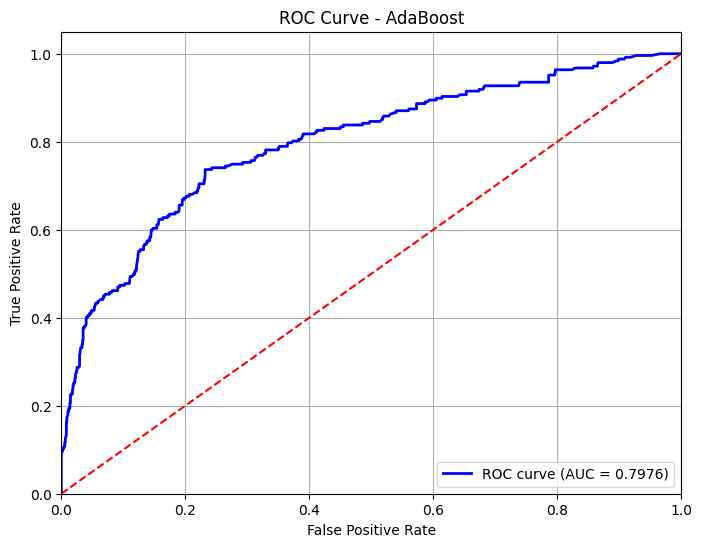

In [51]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get predicted probabilities (for the positive class)
y_prob = AdaBoostClassifier().fit(x_train, y_train).predict_proba(x_test)[:, 1]

# 2. Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 3. Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = {:.4f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - AdaBoost')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
